In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

# Load data processed
df = pd.read_csv("../data/processed/features_toba.csv", parse_dates=["date"])

# Fokus Balige, target suhu maksimum
balige = df[df["location"] == "Balige (Tobasa)"].copy()
balige = balige.sort_values("date").reset_index(drop=True)
balige = balige.set_index("date")

series = balige["temperature_2m_max"]

print(f"Data Balige: {len(series)} hari")
print(f"Periode    : {series.index.min().date()} s/d {series.index.max().date()}")
print(f"Rata-rata  : {series.mean():.2f}°C")

Data Balige: 3624 hari
Periode    : 2015-01-30 s/d 2024-12-31
Rata-rata  : 28.43°C


In [ ]:
def adf_test(series, label=""):
    result = adfuller(series.dropna())
    print(f"  ADF Test: {label} ")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.6f}")
    print(f"  Kesimpulan    : {' STASIONER (p < 0.05)' if result[1] < 0.05 else ' TIDAK STASIONER'}")
    print()
    return result[1] < 0.05

is_stationary = adf_test(series, "Suhu Maks Balige")

if not is_stationary:
    series_diff = series.diff().dropna()
    adf_test(series_diff, "Suhu Maks Balige (differenced)")

 ADF Test: Suhu Maks Balige 
  ADF Statistic : -4.4067
  p-value       : 0.000289
  Kesimpulan    :  STASIONER (p < 0.05)



Train: 2899 hari (2015-01-30 s/d 2023-01-06)
Test : 725 hari (2023-01-07 s/d 2024-12-31)


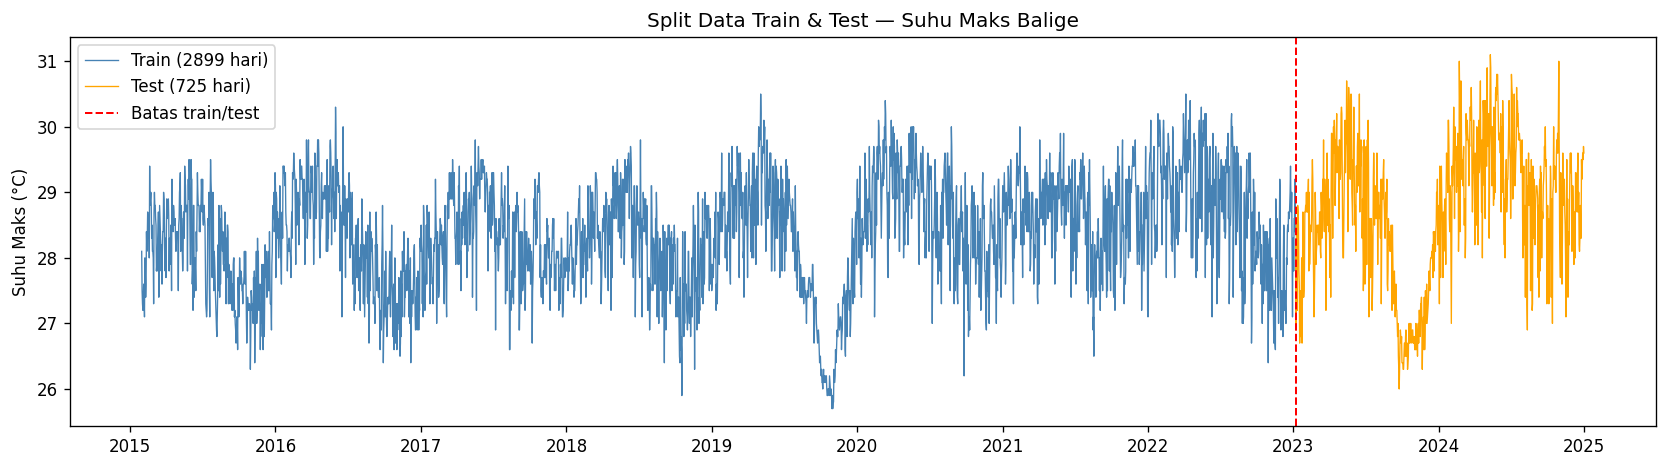

In [3]:
# 80% train, 20% test
split_idx = int(len(series) * 0.8)
train = series.iloc[:split_idx]
test  = series.iloc[split_idx:]

print(f"Train: {len(train)} hari ({train.index.min().date()} s/d {train.index.max().date()})")
print(f"Test : {len(test)} hari ({test.index.min().date()} s/d {test.index.max().date()})")

# Visualisasi split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train, color="steelblue", label=f"Train ({len(train)} hari)", linewidth=0.8)
ax.plot(test.index, test, color="orange", label=f"Test ({len(test)} hari)", linewidth=0.8)
ax.axvline(test.index.min(), color="red", linestyle="--", linewidth=1.2, label="Batas train/test")
ax.set_title("Split Data Train & Test — Suhu Maks Balige")
ax.set_ylabel("Suhu Maks (°C)")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
auto_model = auto_arima(
    train,
    seasonal=True,
    m=7,                  # Musiman mingguan
    stepwise=True,        # Lebih cepat dari exhaustive search
    suppress_warnings=True,
    error_action="ignore",
    information_criterion="aic",
    trace=True            # Tampilkan proses pencarian
)

print(f"\nModel terbaik: ARIMA{auto_model.order} x {auto_model.seasonal_order}")
print(f"AIC: {auto_model.aic():.2f}")
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=4574.947, Time=8.90 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=5338.570, Time=0.36 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=5096.616, Time=0.68 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=4830.450, Time=0.91 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=5336.570, Time=0.08 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=4573.199, Time=5.61 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=4571.377, Time=3.48 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=4573.193, Time=5.73 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=4572.868, Time=1.36 sec
 ARIMA(2,1,1)(0,0,0)[7] intercept   : AIC=4572.889, Time=2.07 sec
 ARIMA(3,1,2)(0,0,0)[7] intercept   : AIC=4573.423, Time=3.69 sec
 ARIMA(2,1,3)(0,0,0)[7] intercept   : AIC=4573.785, Time=4.53 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=4571.044, Time=0.94 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=4573.043, Time=2.61 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept

In [5]:
# Train model SARIMA dengan parameter dari auto_arima
order          = auto_model.order
seasonal_order = auto_model.seasonal_order

print(f"Training SARIMA{order}x{seasonal_order}")

model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted = model.fit(disp=False)
print("Training selesai!")

# Prediksi pada test set
n_periods = len(test)
forecast = fitted.get_forecast(steps=n_periods)
pred_mean = forecast.predicted_mean
pred_ci   = forecast.conf_int(alpha=0.2)  # 80% confidence interval

print(f"\nPrediksi {n_periods} hari ke depan selesai")

Training SARIMA(1, 1, 1)x(0, 0, 0, 7)


d:\LangitToba\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\LangitToba\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Training selesai!

Prediksi 725 hari ke depan selesai


In [6]:
def evaluate(actual, predicted, model_name="Model"):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2   = 1 - np.sum((actual - predicted)**2) / np.sum((actual - actual.mean())**2)

    print(f" Evaluasi {model_name} ")
    print(f"  MAE  : {mae:.3f}°C")
    print(f"  RMSE : {rmse:.3f}°C")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R²   : {r2:.4f}")
    return {"model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

arima_metrics = evaluate(test.values, pred_mean.values, "SARIMA")

 Evaluasi SARIMA 
  MAE  : 0.933°C
  RMSE : 1.112°C
  MAPE : 3.24%
  R²   : -0.0978


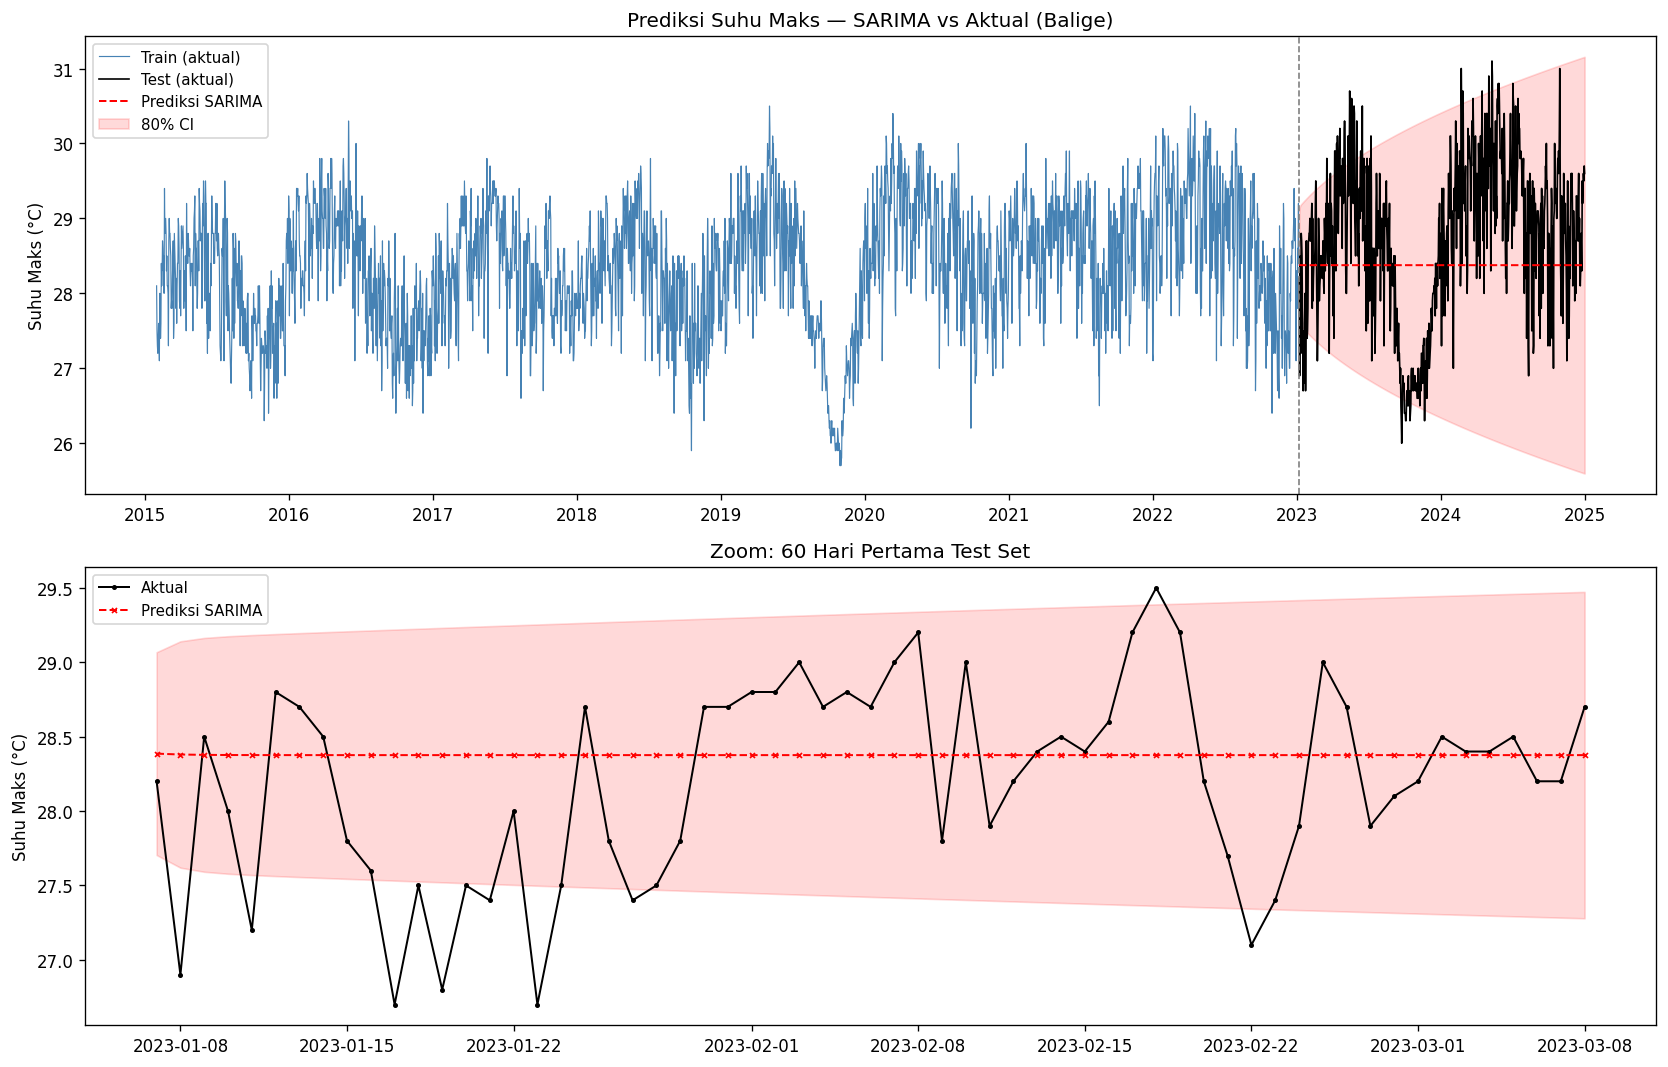

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Plot 1: keseluruhan dengan zoom test
axes[0].plot(train.index, train, color="steelblue", linewidth=0.7, label="Train (aktual)")
axes[0].plot(test.index, test, color="black", linewidth=1, label="Test (aktual)")
axes[0].plot(pred_mean.index, pred_mean, color="red", linewidth=1.2,
             linestyle="--", label="Prediksi SARIMA")
axes[0].fill_between(pred_ci.index,
                     pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                     color="red", alpha=0.15, label="80% CI")
axes[0].axvline(test.index.min(), color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Prediksi Suhu Maks — SARIMA vs Aktual (Balige)")
axes[0].set_ylabel("Suhu Maks (°C)")
axes[0].legend(fontsize=9)

# Plot 2: zoom 60 hari pertama test
zoom_end = test.index[min(60, len(test)-1)]
mask = (test.index <= zoom_end)
axes[1].plot(test.index[mask], test.values[mask], color="black",
             linewidth=1.2, marker="o", markersize=2, label="Aktual")
axes[1].plot(pred_mean.index[mask], pred_mean.values[mask], color="red",
             linewidth=1.2, marker="x", markersize=3, linestyle="--", label="Prediksi SARIMA")
axes[1].fill_between(pred_ci.index[mask],
                     pred_ci.iloc[:, 0][mask], pred_ci.iloc[:, 1][mask],
                     color="red", alpha=0.15)
axes[1].set_title("Zoom: 60 Hari Pertama Test Set")
axes[1].set_ylabel("Suhu Maks (°C)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/07_arima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
import json

# Simpan model
model_path = "../models/arima_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(fitted, f)
print(f"Model disimpan: {model_path}")

# Simpan metrics ke JSON untuk perbandingan nanti
metrics_path = "../models/metrics_comparison.json"
metrics_data = {"SARIMA": arima_metrics}
with open(metrics_path, "w") as f:
    json.dump(metrics_data, f, indent=2)
print(f"Metrics disimpan: {metrics_path}")


print(f"  SARIMA — Ringkasan")

print(f"  Order         : {order}")
print(f"  Seasonal order: {seasonal_order}")
print(f"  MAE           : {arima_metrics['MAE']:.3f}°C")
print(f"  RMSE          : {arima_metrics['RMSE']:.3f}°C")
print(f"  MAPE          : {arima_metrics['MAPE']:.2f}%")
print(f"  R²            : {arima_metrics['R2']:.4f}")


Model disimpan: ../models/arima_model.pkl
Metrics disimpan: ../models/metrics_comparison.json
  SARIMA — Ringkasan
  Order         : (1, 1, 1)
  Seasonal order: (0, 0, 0, 7)
  MAE           : 0.933°C
  RMSE          : 1.112°C
  MAPE          : 3.24%
  R²            : -0.0978
